## Autoencoders Lab
#### visualizing HapMap phase 3 populations

**This is a solution template. Every chunk of code requiring your input will begin with the # TASK comment and all places where you should fill-in with your code are marked by ellipsis (...).**

### Stage 0 &mdash; getting the data

First, we will download the data from the linked Dropbox account. The code is hidden as it is not super important here. Double-click below if you are curious to see it!



In [1]:
#@title Load raw data. Double click to see the code. { display-mode: "form" }

!wget https://www.dropbox.com/s/g7862q1l4ls9z3x/autosomal_5k_matrix.csv
!wget https://www.dropbox.com/s/3lv0062dw20qdqg/autosomal_5k_phenos.csv
!wget https://www.dropbox.com/s/6nzrusxkm536a5j/autosomal_5k_kinship.csv

--2026-07-01 19:28:40--  https://www.dropbox.com/s/g7862q1l4ls9z3x/autosomal_5k_matrix.csv
Resolving www.dropbox.com (www.dropbox.com)... 162.125.66.18, 2620:100:6022:18::a27d:4212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.66.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/a6mehjrpky5u3kwqle74i/autosomal_5k_matrix.csv?rlkey=1iufpj9nhjrm9q3f9ah0msq1d [following]
--2026-07-01 19:28:41--  https://www.dropbox.com/scl/fi/a6mehjrpky5u3kwqle74i/autosomal_5k_matrix.csv?rlkey=1iufpj9nhjrm9q3f9ah0msq1d
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc100197e4df24ab0aee0b2a5f9c.dl.dropboxusercontent.com/cd/0/inline/DDfju77_AdtIBCjaGHjraVKW7rwysCxm3U_qo0i6Cji6Iw-OMGmmQg3VC-v5KZXVWss8E8zPfAY6FMZMLZ6czI7T1T3IayPrnq6w74Kk9WVc2f0KVdjOKToazgSWiCik2AY/file# [following]
--2026-07-01 19:28:41--  https://uc100197e4df24ab0aee0b2a5f9c.dl.dropboxusercontent.co

Now, we will load the data and make sure they look as expected. Note, the genotypes per individual (row) are encoded as the count of minor alleles and thus can take values `gt = {0, 1, 2}`.

In [21]:
import numpy as np
import pandas as pd
import tensorflow as tf

# tf.config.optimizer.set_jit(False)

import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from matplotlib import pyplot as plt
from tensorflow.keras.utils import plot_model

data = pd.read_csv("autosomal_5k_matrix.csv", header=0, index_col=0)
pheno = pd.read_csv("autosomal_5k_phenos.csv", header=0, index_col=0)

print(data)
print(pheno)


         rs416967  rs17013842  rs13052452  rs11049986  rs10994341  rs1504289  \
NA19919         2           1           0           1           1          0   
NA19916         1           0           0           1           1          0   
NA19835         0           0           1           1           0          1   
NA20282         1           1           0           1           0          0   
NA19703         0           0           0           0           1          1   
...           ...         ...         ...         ...         ...        ...   
NA19119         1           0           1           0           1          1   
NA18860         1           0           0           1           1          0   
NA19207         2           0           0           0           1          0   
NA19103         1           0           1           0           0          0   
NA19099         0           0           1           1           0          1   

         rs882529  rs3885937  rs537330 

How many individuals do we have in the dataset?

1184

How many individuals per population do we have?  
MKK    171,
YRI    167,
CEU    165,
LWK     90,
GIH     88,
TSI     88,
JPT     86,
CHD     85,
CHB     84,
ASW     83,
MEX     77,

Do they have the same number of males and females?

Only CHB with both 42 individuals and TSI with 44 individuals of each sex have exactly the same number of males and females.

How many full- and half-siblings do we have in the dataset?

Even though I am a bit suspicious there is a flaw in my logic, but there seem to be no half- or full siblings.

How many families do we have?
770

In [3]:
print(pheno['population'].value_counts())
print(pd.crosstab(pheno['population'], pheno['sex']))
num_families = pheno['FID'].nunique()

print(f"Total number of families: {num_families}")

known_parents = pheno[(pheno['dad'] != 0) & (pheno['dad'] != '0') &
                   (pheno['mom'] != 0) & (pheno['mom'] != '0')]

parent_combos = known_parents.groupby(['dad', 'mom']).size()

full_sib_groups = parent_combos[parent_combos > 1]
print(f"Number of full-sibling groups (families): {len(full_sib_groups)}")
print(f"Number of individuals with at least one full sibling: {full_sib_groups.sum()}")

known_dads = pheno[(pheno['dad'] != 0) & (pheno['dad'] != '0')]
known_moms = pheno[(pheno['mom'] != 0) & (pheno['mom'] != '0')]

paternal_partners = known_dads.groupby('dad')['mom'].nunique()
dads_with_multi_partners = paternal_partners[paternal_partners > 1].index

maternal_partners = known_moms.groupby('mom')['dad'].nunique()
moms_with_multi_partners = maternal_partners[maternal_partners > 1].index

paternal_half_sibs = pheno[pheno['dad'].isin(dads_with_multi_partners)]
maternal_half_sibs = pheno[pheno['mom'].isin(moms_with_multi_partners)]

all_half_sib_ids = set(paternal_half_sibs['id']).union(set(maternal_half_sibs['id']))

print(f"Total individuals who are paternal half-siblings: {len(paternal_half_sibs)}")
print(f"Total individuals who are maternal half-siblings: {len(maternal_half_sibs)}")
print(f"Total unique individuals with ANY half-sibling: {len(all_half_sib_ids)}")

population
MKK    171
YRI    167
CEU    165
LWK     90
GIH     88
TSI     88
JPT     86
CHD     85
CHB     84
ASW     83
MEX     77
Name: count, dtype: int64
sex          0   1
population        
ASW         45  38
CEU         85  80
CHB         42  42
CHD         44  41
GIH         43  45
JPT         42  44
LWK         45  45
MEX         43  34
MKK         85  86
TSI         44  44
YRI         77  90
Total number of families: 770
Number of full-sibling groups (families): 0
Number of individuals with at least one full sibling: 0
Total individuals who are paternal half-siblings: 0
Total individuals who are maternal half-siblings: 0
Total unique individuals with ANY half-sibling: 0


In [4]:
# Check if there is at least one duplicate dad (excluding 0)
has_shared_dad = pheno[(pheno['dad'] != 0) & (pheno['dad'] != '0')]['dad'].duplicated().any()

# Check if there is at least one duplicate mom (excluding 0)
has_shared_mom = pheno[(pheno['mom'] != 0) & (pheno['mom'] != '0')]['mom'].duplicated().any()

print(f"Are there shared dads? {has_shared_dad}")
print(f"Are there shared moms? {has_shared_mom}")

Are there shared dads? False
Are there shared moms? False


In [5]:
family_sizes = pheno['FID'].value_counts()

print("Distribution of Family Sizes:")
print(family_sizes.value_counts().sort_index())

Distribution of Family Sizes:
count
1    563
2     60
3    122
4      3
5      9
6     13
Name: count, dtype: int64


Now, we will create a dictionary and re-name our populations so that the names are a bit more informative:

In [6]:
pop_dict = {'ASW':'African ancestry in SW USA',
            'CEU':'Utah residents with N and W European ancestry',
            'CHB':'Han Chinese in Beijing China',
            'CHD':'Chinese in Metropolitan Denver Colorado',
            'GIH':'Gujarati Indians in Houston Texas',
            'JPT':'Japanese in Tokyo Japan',
            'LWK':'Luhya in Webuye Kenya',
            'MEX':'Mexican ancestry in Los Angeles California',
            'MKK':'Maasai in Kinyawa Kenya',
            'TSI':'Toscans in Italy',
            'YRI':'Yoruba in Ibadan Nigeria'}
pheno2 = pheno.replace({"population": pop_dict})
pheno2

,id,sex,FID,dad,mom,pheno,population
NA19919,NA19919,1,2427,NA19908,NA19909,0,African ancestry in SW USA
NA19916,NA19916,1,2431,0,0,0,African ancestry in SW USA
NA19835,NA19835,0,2424,0,0,0,African ancestry in SW USA
NA20282,NA20282,0,2469,0,0,0,African ancestry in SW USA
NA19703,NA19703,1,2368,0,0,0,African ancestry in SW USA
...,...,...,...,...,...,...,...
NA19119,NA19119,1,Y060,0,0,0,Yoruba in Ibadan Nigeria
NA18860,NA18860,1,Y012,NA18859,NA18858,0,Yoruba in Ibadan Nigeria
NA19207,NA19207,1,Y051,0,0,0,Yoruba in Ibadan Nigeria
NA19103,NA19103,1,Y042,NA19101,NA19102,0,Yoruba in Ibadan Nigeria


In [7]:
# TASK Scaling
# We need to scale our counts data so that it is bound between 0 and 1.

geno_data = data / 2
geno_data

,rs416967,rs17013842,rs13052452,rs11049986,rs10994341,rs1504289,rs882529,rs3885937,rs537330,rs9372090,...,rs1558766,rs7818288,rs1051685,rs11223492,rs789492,rs6557516,rs7313246,rs317892,rs11937009,rs2806497
NA19919,1.0,0.5,0.0,0.5,0.5,0.0,0.0,0.5,0.5,0.5,...,0.0,0.5,0.0,0.0,0.5,0.0,0.5,0.5,0.5,0.0
NA19916,0.5,0.0,0.0,0.5,0.5,0.0,0.5,0.5,1.0,0.5,...,0.0,0.0,0.0,0.0,0.0,0.5,0.5,0.5,0.5,0.0
NA19835,0.0,0.0,0.5,0.5,0.0,0.5,0.0,1.0,1.0,0.5,...,0.0,0.5,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
NA20282,0.5,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.5,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.5,1.0,0.0,0.0
NA19703,0.0,0.0,0.0,0.0,0.5,0.5,0.0,0.0,0.0,1.0,...,0.0,0.5,0.5,0.0,0.5,0.5,0.5,0.5,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NA19119,0.5,0.0,0.5,0.0,0.5,0.5,0.5,0.5,0.5,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0
NA18860,0.5,0.0,0.0,0.5,0.5,0.0,0.0,0.5,1.0,0.5,...,0.5,0.5,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.5
NA19207,1.0,0.0,0.0,0.0,0.5,0.0,0.5,0.5,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.5,0.5,0.0
NA19103,0.5,0.0,0.5,0.0,0.0,0.0,0.5,0.5,1.0,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.5,1.0,0.0


In [8]:
# TASK Randomly split into the training and the validation set, so that 80 per-cent of individuals ends up in the training set.

train = geno_data.sample(frac = 0.8, random_state = 42)
test = geno_data.drop(train.index)
train.reset_index()
test.reset_index()

# TASK Print some info about the resulting split
print("Total number of individuals:", train.shape[0] + test.shape[0])
print("\t - training set:", train.shape[0])
print("\t - test set:", test.shape[0])

Total number of individuals: 1184
	 - training set: 947
	 - test set: 237


/tmp/ipykernel_16398/2916920320.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train.reset_index()
/tmp/ipykernel_16398/2916920320.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test.reset_index()


In [ ]:
from os import name
# TASK Specify the autoencoder model

train_tensor = train.to_numpy()
print(type(train_tensor))

# TASK Hyperparameters
# use ReLu activations, ADAM optimizer and
# mean squared error as the loss function
hp_loss_fn = keras.losses.MSE
hp_act_fn = keras.activations.relu
hp_optimizer = 'adam'
hp_metrics = ['mse','mae','mape']

input_data = keras.Input(shape = (train_tensor.shape[1],))

# TASK Define architecture of the encoder:
# the second layer should be a batch normalization

def Encoder(input):
  # Encoder
  layer1 = layers.Dense(units = 1500, activation = hp_act_fn, name='layer1')(input)
  layer2 = layers.BatchNormalization(name='layer2')(layer1)
  layer3 = layers.Dropout(rate = 0.05, name='layer3')(layer2)
  layer4 = layers.Dense(units = 250, activation = hp_act_fn, name='layer4')(layer3)
  layer5 = layers.Dropout(rate = 0.025, name='layer5')(layer4)
  layer6 = layers.Dense(units = 25, activation = hp_act_fn, name='layer6')(layer5)
  bottleneck = layers.Dense(units = 2, name='layer_bottleneck')(layer6)
  return(bottleneck)

# TASK Look at the encoder, complete the decoder function

def Decoder(bottleneck):
  # Decoder
  layer7 = layers.Dense(units = 25, activation = hp_act_fn)(bottleneck)
  layer8 = layers.Dropout(rate = 0.025)(layer7)
  layer9 = layers.Dense(units = 250, activation = hp_act_fn)(layer8)
  layer10 = layers.Dropout(rate = 0.05)(layer9)
  layer11 = layers.Dense(units = 1500, activation = hp_act_fn)(layer10)
  layer12 = layers.Dense(units = train_tensor.shape[1], activation = 'sigmoid')(layer11)
  return(layer12)

def Autoencoder(input):
  enc = Encoder(input)
  autoenc = Decoder(enc)
  return(autoenc)

autoencoder_model = keras.Model(inputs = input_data, outputs = Autoencoder(input_data))
autoencoder_model.compile(
  loss = hp_loss_fn,
  optimizer = hp_optimizer,
  metrics = hp_metrics
)

# TASK Visualise the created architecture and summarise its parameters
autoencoder_model.summary()
# plot_model(autoencoder_model, show_shapes=True, show_layer_names=True)

<class 'numpy.ndarray'>


I0000 00:00:1782934129.712397   16398 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15102 MB memory:  -> device: 0, name: AMD Radeon RX 6950 XT, pci bus id: 0000:03:00.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer1 (Dense)                  │ (None, 1500)           │     7,501,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (BatchNormalization)     │ (None, 1500)           │         6,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dropout)                │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4 (Dense)                  │ (None, 250)            │       375,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer5 (Dropout)                │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer6 (Dense)                  │ (None, 25)             │         6,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_bottleneck (Dense)        │ (None, 2)              │            52 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │            75 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 250)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1500)           │       376,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5000)           │     7,505,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,777,152 (60.19 MB)

 Trainable params: 15,774,152 (60.17 MB)

 Non-trainable params: 3,000 (11.72 KB)

In [10]:
# TASK Set hyperparameters for model fitting
# Begin by training for 30 epochs, with mini-batch of 256 and validation set
# having 20 per-cent of examples
hp_epochs = 30
hp_batch_size = 64
hp_val_split = 0.2



autoencoder = autoencoder_model.fit(x = train_tensor,
                      y = train_tensor,
                      epochs = hp_epochs,
                      batch_size = hp_batch_size,
                      shuffle = True,
                      validation_split = hp_val_split,
                      )

Epoch 1/30


2026-07-01 19:28:51.376792: I external/local_xla/xla/service/service.cc:163] XLA service 0x730c90014f40 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
2026-07-01 19:28:51.376802: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): AMD Radeon RX 6950 XT, AMDGPU ISA version: gfx1030
2026-07-01 19:28:51.405200: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-01 19:28:51.696677: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-01 19:28:51.696820: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of

 8/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1700 - mae: 0.3556 - mape: 317403512.0000 - mse: 0.1700 

I0000 00:00:1782934139.218466   16512 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-07-01 19:28:59.599634: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-01 19:28:59.599802: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-01 19:28:59.599860: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set do

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 858ms/step - loss: 0.1562 - mae: 0.3322 - mape: 282059222.6667 - mse: 0.1562

2026-07-01 19:29:08.835291: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-01 19:29:10.601989: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


12/12 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - loss: 0.1224 - mae: 0.2716 - mape: 192820544.0000 - mse: 0.1224 - val_loss: 0.0747 - val_mae: 0.1809 - val_mape: 87006328.0000 - val_mse: 0.0747
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0761 - mae: 0.1706 - mape: 62518292.0000 - mse: 0.0761 - val_loss: 0.0723 - val_mae: 0.1888 - val_mape: 104784408.0000 - val_mse: 0.0723
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0699 - mae: 0.1816 - mape: 85470224.0000 - mse: 0.0699 - val_loss: 0.0701 - val_mae: 0.2081 - val_mape: 124078944.0000 - val_mse: 0.0701
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0671 - mae: 0.1881 - mape: 91484216.0000 - mse: 0.0671 - val_loss: 0.0705 - val_mae: 0.2154 - val_mape: 134440688.0000 - val_mse: 0.0705
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0658 - mae: 0.1885 - mape: 94086288.0000 - mse: 0.0658 - val_loss: 0.0688 - val_mae: 0.2105 - val_mape: 128886760.0000 - val_mse: 0.0688
Epoch 6/30
12/12 ━━━━━━━━

Now, let us look at the training process:

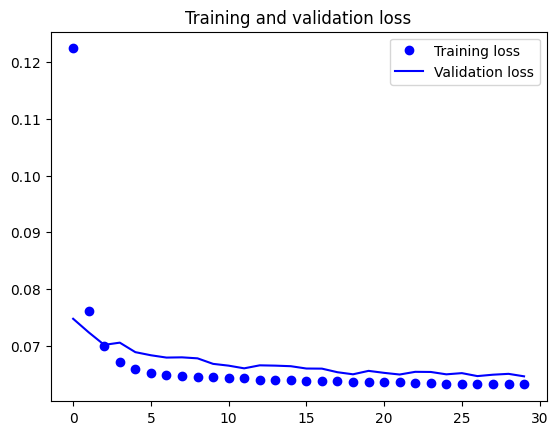

In [11]:
loss = autoencoder.history['loss']
val_loss = autoencoder.history['val_loss']
epochs = range(hp_epochs)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

Now, that the model is trained, we can save the weights and use them to build an encoder. Note that weights are saved for the entire autoencoder, so we need to use `skip_mismatch = True` along with `by_name = True` to initialize weights in our encoder.

In [12]:
autoencoder_model.save_weights('autoencoder_weights.weights.h5',
                               overwrite = True)

encoder_model = keras.Model(inputs = input_data, outputs = Encoder(input_data))
encoder_model.load_weights('autoencoder_weights.weights.h5',
                           skip_mismatch = True)
encoder_model.compile(
  loss = hp_loss_fn,
  optimizer = hp_optimizer,
  metrics = hp_metrics,
)


Let us embed our genotyping data using the encoder we have just constructed.
We can also visualise the embedding.

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[[ -1.6509289  -15.344961  ]
 [ -0.74414444 -13.978802  ]
 [  0.60317844 -14.759393  ]
 ...
 [ -0.86725897 -15.56379   ]
 [ -1.4170437  -14.768223  ]
 [ -1.6707455  -15.912585  ]]


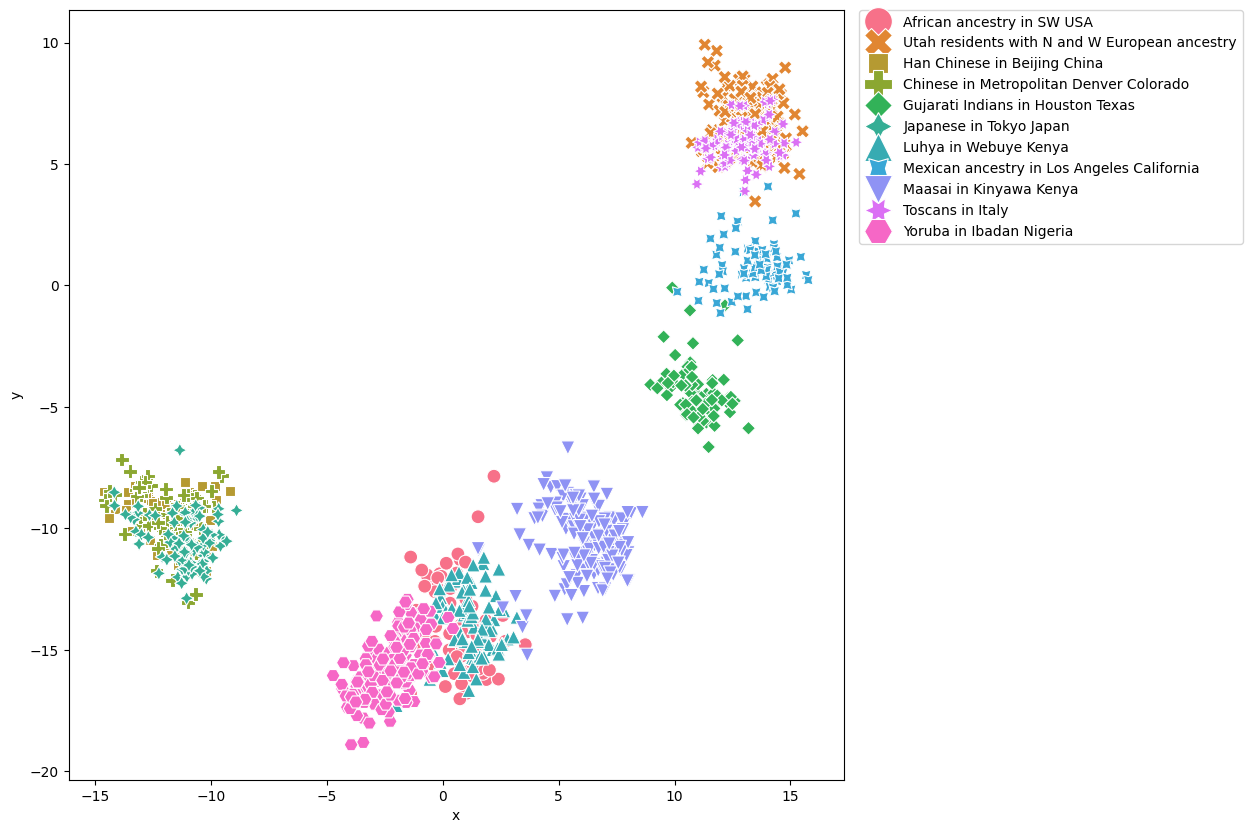

In [13]:
embeded_points = encoder_model.predict(geno_data.to_numpy())
print(embeded_points)

x = embeded_points[:,0]
y = embeded_points[:,1]
pop = pheno2['population']
data = {'x':x, 'y':y, 'pop':pop}
plt.figure(figsize = (10,10))
sns.scatterplot(x='x', y='y', data=data, hue='pop', style='pop', s=100)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, markerscale=2)
plt.show()

Now, we will compare the result with:
* MDS on the kinship matrix
* PCA perfored directly on raw genotypes


In [14]:
kinship = pd.read_csv("autosomal_5k_kinship.csv", header=0, index_col=0)


In [15]:
from sklearn.manifold import MDS
embedding = MDS(n_components=2)
mds_embedding = embedding.fit_transform(kinship)


/opt/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/opt/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:775: UserWarning: The provided input is a square matrix. Note that ``fit`` constructs a dissimilarity matrix from data and will treat rows as samples and columns as features. To use a pre-computed dissimilarity matrix, set ``metric='precomputed'``.
  warnings.warn(


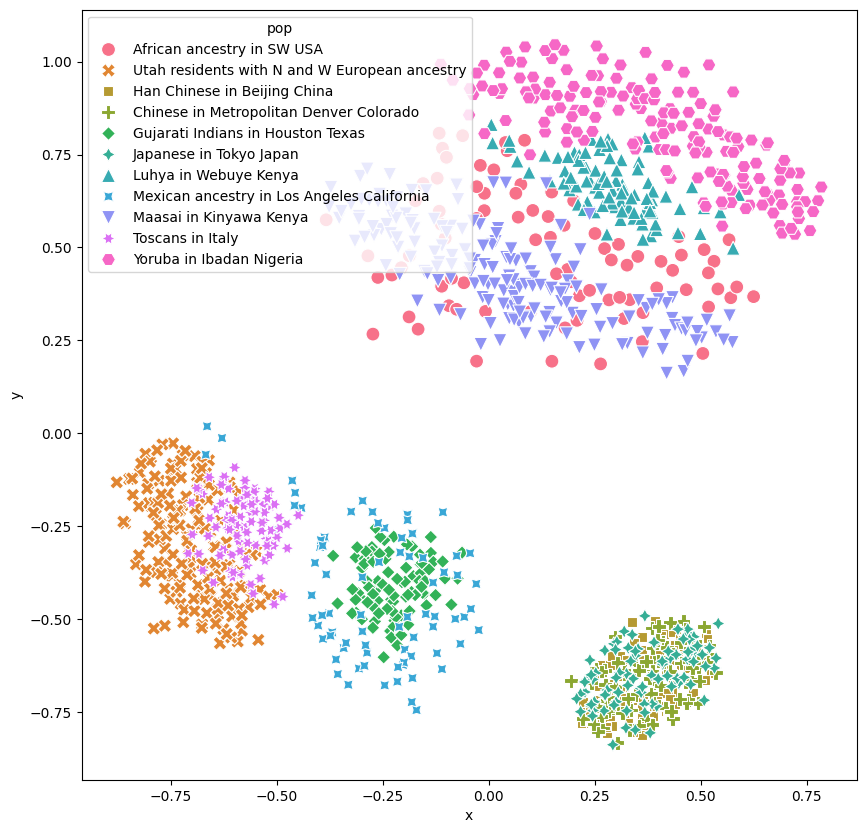

In [16]:
# TASK Plot MDS embedding in a way similar to plotting autoencoder embeddings
x = mds_embedding[:,0]
y = mds_embedding[:,1]
pop = pheno2['population']
data = {'x':x, 'y':y, 'pop':pop}
plt.figure(figsize = (10,10))
sns.scatterplot(x='x', y='y', data=data, hue='pop', style='pop', s=100)
plt.show()

Finally, we will perform PCA on raw genotypes:

In [17]:
# TASK perform PCA with 2 components on raw genotypes (use geno_data as input but remember it has been scaled)
# Visualise the result.
from sklearn.decomposition import PCA
embedding = PCA(n_components=2)
pca_embedding = embedding.fit_transform(geno_data)


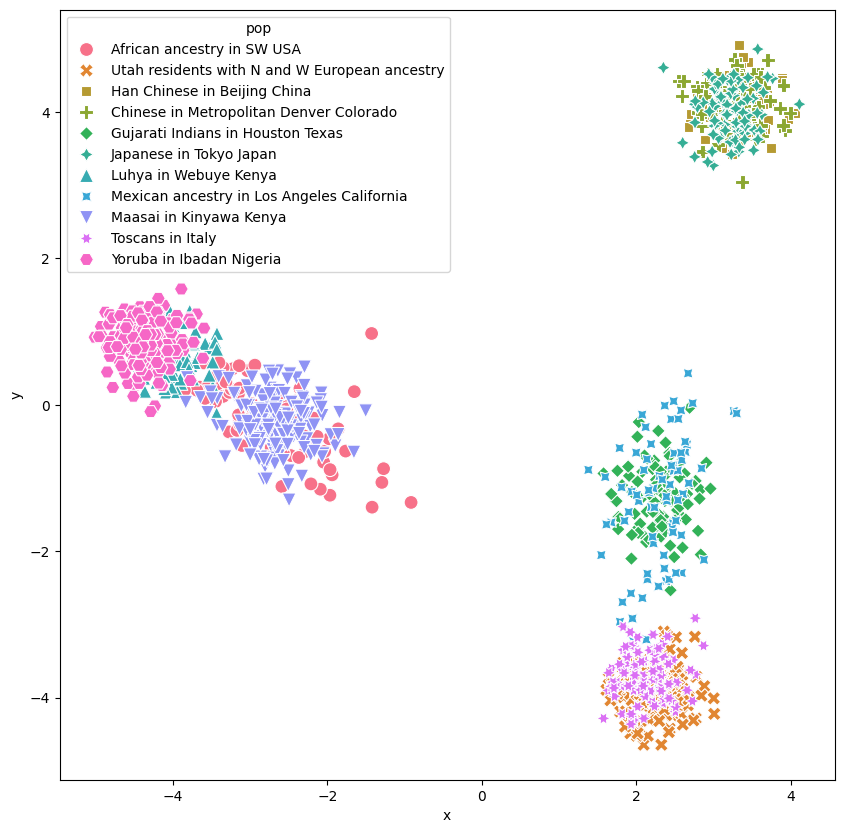

In [18]:
x = pca_embedding[:,0]
y = pca_embedding[:,1]
pop = pheno2['population']
data = {'x':x, 'y':y, 'pop':pop}
plt.figure(figsize = (10,10))
sns.scatterplot(x='x', y='y', data=data, hue='pop', style='pop', s=100)

# plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, markerscale=2)
plt.show()

Do you see a significant difference between MDS on the kinship matrix, PCA on raw genotypes and Autoencoder embedding on the raw genotypes?

Yes, there are significant differences. For one, only PCA seems to result in the same solution with every rerun. Both MDS and the Autoencoder lead to different results with reruns. While the clusters produced by the Autoencoder differ strongly in their relationship to each other, and even which populations get clustered in similar regions, MDS always clusters the same populations together and only changes the relative position of the clusters to each other.

Do they have the similar resolution?

They all have different scales. The largest scale is from the autoencoder, then PCA and then MDS.

Are they equally good in separating populations?

MDS and PCA have four big clusters. Three of these clusters consist of two or more populations in the same location on the graph. The fourth cluster has some spatial segregation of the different populations.
The Autoencoder has six different clusters, so a bigger separation of populations. Nontheless there are clusters made up of multiple populations, which are also present with the other methods.

Are there any populations with high/low gene-flow?

Yes, as mentioned in the question above, there seems to be high gene-flow for CHD, CHB and JPT, as well as ASW, YRI, LWK and MKK. When analyzing with PCA or MDS there also seems to be high gene-flow for CEU and TSI, as well as GIH and MEX.
The regions of high gene-flow have a stronger separations between them. All clusters far away from each other can be considered low gene-flow to each other.

How do the methods perform with regards to outliers?
Autoencoder should be the most robust, but until now there is not much of a difference visible, as we don't have any missing values in our data.

In [25]:

# Autoencoder 2

# using another activation function and a different loss function to make it more robust to outliers
hp_loss_fn_2 = keras.losses.MAE
hp_act_fn_1 = keras.layers.LeakyReLU(alpha=0.1)
def Encoder_2(input):
  # Encoder
  layer1 = layers.Dense(units = 1500, activation = hp_act_fn_1, name='layer1')(input)
  layer2 = layers.BatchNormalization(name='layer2')(layer1)
  layer3 = layers.Dropout(rate = 0.05, name='layer3')(layer2)
  layer4 = layers.Dense(units = 250, activation = hp_act_fn_1, name='layer4')(layer3)
  layer5 = layers.Dropout(rate = 0.025, name='layer5')(layer4)
  layer6 = layers.Dense(units = 50, activation = hp_act_fn_1, name='layer6')(layer5)
  bottleneck = layers.Dense(units = 2, name='layer_bottleneck')(layer6)
  return(bottleneck)

def Decoder_2(bottleneck):
  # Decoder
  layer7 = layers.Dense(units = 50, activation = hp_act_fn_1)(bottleneck)
  layer8 = layers.Dropout(rate = 0.025)(layer7)
  layer9 = layers.Dense(units = 250, activation = hp_act_fn_1)(layer8)
  layer10 = layers.Dropout(rate = 0.05)(layer9)
  layer11 = layers.Dense(units = 1500, activation = hp_act_fn_1)(layer10)
  layer12 = layers.Dense(units = train_tensor.shape[1], activation = 'sigmoid')(layer11)
  return(layer12)

def Autoencoder_2(input):
  enc = Encoder_2(input)
  autoenc = Decoder_2(enc)
  return(autoenc)

/opt/venv/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Going from MSE to MAE makes the effect of outliers much smaller. MAE applies a linear penalty.

Using LeakyReLU avoids "dead neurons".  This can preserve weak genetifc signals.

Changing the bottleneck from 25 to 50 should soften the bottleneck by avoiding overly harsh compression before it;./

In [24]:
# Autoencoder 3

def Encoder_3(input):
  # Shallow network: Jumps straight from 5000 to 250
  # L1 Regularization acts as a genetic feature selector
  layer1 = layers.Dense(
      250, 
      activation=hp_act_fn, 
      activity_regularizer=regularizers.l1(1e-4)
  )(input)
  layer2 = layers.BatchNormalization()(layer1)
  layer3 = layers.Dropout(0.2)(layer2) # Heavy dropout to prevent overfitting
  bottleneck = layers.Dense(2, name='layer_bottleneck')(layer3)
  return bottleneck

def Decoder_3(bottleneck):
  layer1 = layers.Dense(250, activation=hp_act_fn)(bottleneck)
  layer2 = layers.Dropout(0.2)(layer1) # Heavy dropout to prevent overfitting
  layer3 = layers.Dense(5000, activation='sigmoid')(layer2)
  return layer3

def Autoencoder_3(input):
  enc = Encoder_3(input)
  autoenc = Decoder_3(enc)
  return autoenc

By building a shallow Autoencoder, the model acts more like a non-linear PCA, which should be sufficient for this case. 
Using the L1 regularization should make it robust against noise.
Because the architecture is shallow, I increased the Dropout to a high value to ensure it properly generalizes.

In [26]:
autoencoder_model_2 = keras.Model(inputs = input_data, outputs = Autoencoder_2(input_data))
autoencoder_model_2.compile(
  loss = hp_loss_fn_2,
  optimizer = hp_optimizer,
  metrics = hp_metrics
)

In [27]:
hp_epochs = 30
hp_batch_size = 64
hp_val_split = 0.2

autoencoder = autoencoder_model_2.fit(x = train_tensor,
                      y = train_tensor,
                      epochs = hp_epochs,
                      batch_size = hp_batch_size,
                      shuffle = True,
                      validation_split = hp_val_split,
                      )

Epoch 1/30


2026-07-01 20:22:05.234258: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-01 20:22:05.234293: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-01 20:22:05.234346: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-01 20:22:05.234360: I external/l

 8/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3573 - mae: 0.3573 - mape: 322549892.0000 - mse: 0.1731 

2026-07-01 20:22:12.659476: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-01 20:22:12.659500: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-01 20:22:12.659550: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-01 20:22:12.659561: I external/l

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - loss: 0.3337 - mae: 0.3337 - mape: 288147734.6667 - mse: 0.1598

2026-07-01 20:22:21.304155: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-01 20:22:21.304178: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - loss: 0.2719 - mae: 0.2719 - mape: 195624704.0000 - mse: 0.1283 - val_loss: 0.1690 - val_mae: 0.1690 - val_mape: 28554970.0000 - val_mse: 0.0915
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1810 - mae: 0.1810 - mape: 16187898.0000 - mse: 0.1110 - val_loss: 0.1821 - val_mae: 0.1821 - val_mape: 12270980.0000 - val_mse: 0.1133
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1825 - mae: 0.1825 - mape: 11129012.0000 - mse: 0.1148 - val_loss: 0.1804 - val_mae: 0.1804 - val_mape: 12886539.0000 - val_mse: 0.1109
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1771 - mae: 0.1771 - mape: 17639760.0000 - mse: 0.1045 - val_loss: 0.1743 - val_mae: 0.1743 - val_mape: 24609760.0000 - val_mse: 0.0970
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1709 - mae: 0.1709 - mape: 23923362.0000 - mse: 0.0959 - val_loss: 0.1698 - val_mae: 0.1698 - val_mape: 35447232.0000 - val_mse: 0.0882
Epoch 6/30
12/12 ━━━━━━━━━

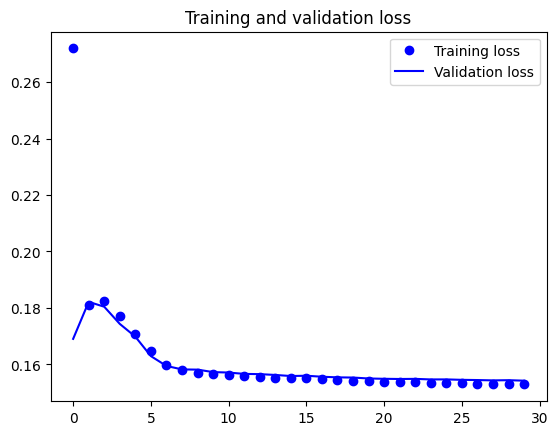

In [28]:
loss = autoencoder.history['loss']
val_loss = autoencoder.history['val_loss']
epochs = range(hp_epochs)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [29]:
autoencoder_model_2.save_weights('autoencoder_model_2_weights.weights.h5',
                               overwrite = True)

encoder_model = keras.Model(inputs = input_data, outputs = Encoder(input_data))
encoder_model.load_weights('autoencoder_model_2_weights.weights.h5',
                           skip_mismatch = True)
encoder_model.compile(
  loss = hp_loss_fn_2,
  optimizer = hp_optimizer,
  metrics = hp_metrics,
)

/opt/venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:640: UserWarning: A total of 2 objects could not be loaded. Example error message for object <Dense name=layer6, built=True>:

The shape of the target variable and the shape of the target value in `variable.assign(value)` must match. variable.shape=(250, 25), Received: value.shape=(250, 50). Target variable: <Variable path=layer6/kernel, shape=(250, 25), dtype=float32, value=[[-1.35870576e-01  5.78046441e-02  1.28627211e-01 ... -8.30479488e-02
  -1.14630193e-01  1.84220970e-02]
 [ 7.56367147e-02 -3.99315432e-02  2.73515880e-02 ... -1.93403661e-03
   1.42194629e-01 -8.03321600e-05]
 [-4.37608734e-02 -1.35131627e-01  2.65249163e-02 ... -7.49910548e-02
  -2.52956003e-02 -1.02270484e-01]
 ...
 [-9.38544869e-02 -8.83098915e-02 -5.79304025e-02 ...  4.89552319e-03
   1.14093214e-01  9.35969502e-02]
 [ 3.51603776e-02 -8.30804855e-02 -2.68951431e-02 ...  1.34491503e-01
  -8.89984518e-02  9.12258029e-02]
 [-3.81432474e-03 -3.4

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
[[-2.6942146  1.8456475]
 [-2.3139884  1.4711828]
 [-2.6983173  2.826704 ]
 ...
 [-2.942843   1.8788164]
 [-2.6788657  2.1111808]
 [-4.416487   3.275729 ]]


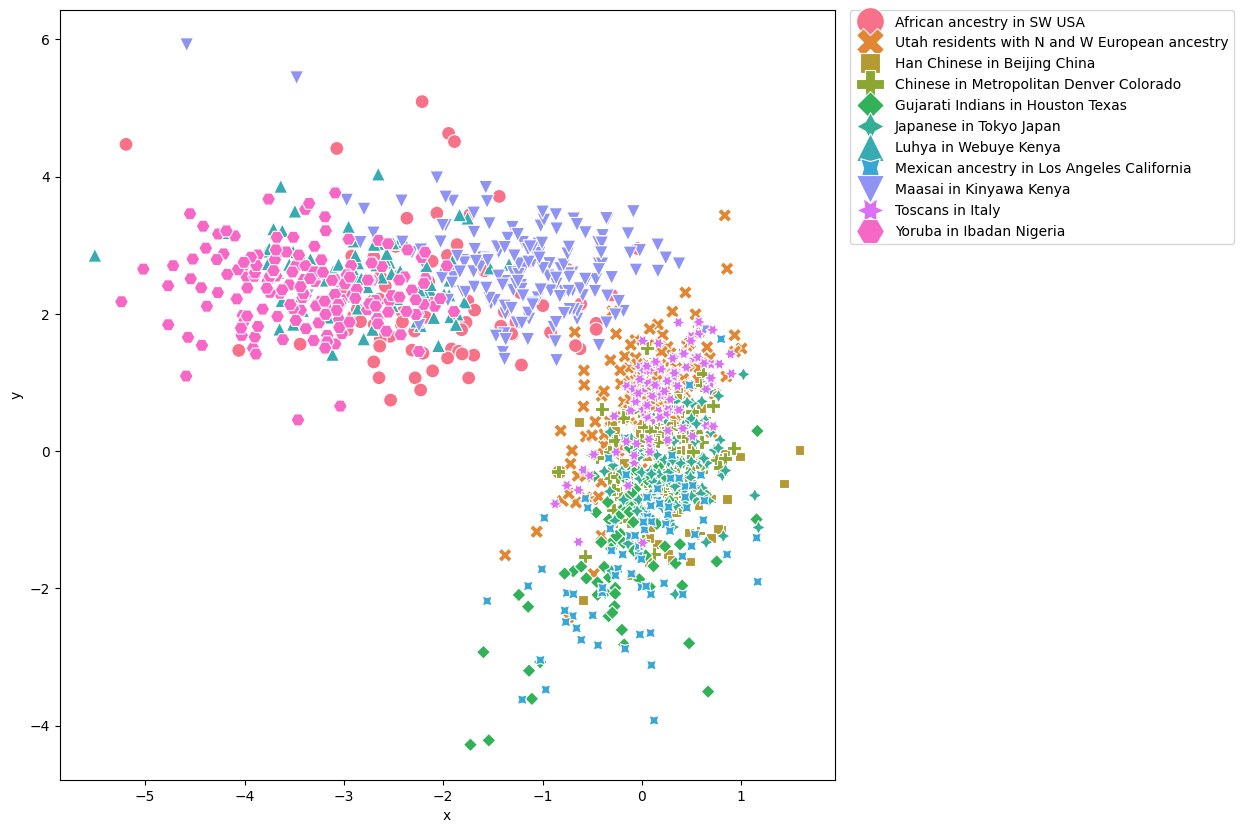

In [30]:
embeded_points = encoder_model.predict(geno_data.to_numpy())
print(embeded_points)

x = embeded_points[:,0]
y = embeded_points[:,1]
pop = pheno2['population']
data = {'x':x, 'y':y, 'pop':pop}
plt.figure(figsize = (10,10))
sns.scatterplot(x='x', y='y', data=data, hue='pop', style='pop', s=100)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, markerscale=2)
plt.show()

The separation between the different populations is worse than with the first Autoencoder architecture. Because outliers were less penalized (MAE), this may also show, that most human populations are not that diffrent from each other on average. A continuous connection between Asian, European and African populations becomes visible.

In [31]:
autoencoder_model_3 = keras.Model(inputs = input_data, outputs = Autoencoder_3(input_data))
autoencoder_model_3.compile(
  loss = hp_loss_fn,
  optimizer = hp_optimizer,
  metrics = hp_metrics
)

In [32]:
autoencoder = autoencoder_model_3.fit(x = train_tensor,
                      y = train_tensor,
                      epochs = hp_epochs,
                      batch_size = hp_batch_size,
                      shuffle = True,
                      validation_split = hp_val_split,
                      )

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 537ms/step - loss: 0.1819 - mae: 0.3678 - mape: 336974080.0000 - mse: 0.1811 - val_loss: 0.1798 - val_mae: 0.3655 - val_mape: 334670688.0000 - val_mse: 0.1790
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1489 - mae: 0.3398 - mape: 295547232.0000 - mse: 0.1473 - val_loss: 0.1295 - val_mae: 0.3215 - val_mape: 268697984.0000 - val_mse: 0.1267
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0948 - mae: 0.2727 - mape: 195381280.0000 - mse: 0.0919 - val_loss: 0.0812 - val_mae: 0.2524 - val_mape: 167722944.0000 - val_mse: 0.0786
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0730 - mae: 0.2180 - mape: 119587328.0000 - mse: 0.0707 - val_loss: 0.0743 - val_mae: 0.2322 - val_mape: 147425376.0000 - val_mse: 0.0727
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0682 - mae: 0.2003 - mape: 103704304.0000 - mse: 0.0670 - val_loss: 0.0784 - val_mae: 0.2438 - val_mape: 170867840.0000 - val_mse: 0.0774
Epoch 6/

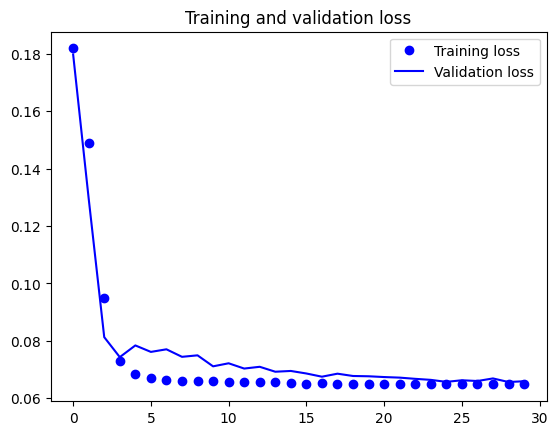

In [33]:
loss = autoencoder.history['loss']
val_loss = autoencoder.history['val_loss']
epochs = range(hp_epochs)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [35]:
autoencoder_model_3.save_weights('autoencoder_model_3_weights.weights.h5',
                               overwrite = True)

encoder_model = keras.Model(inputs = input_data, outputs = Encoder(input_data))
encoder_model.load_weights('autoencoder_model_3_weights.weights.h5',
                           skip_mismatch = True)
encoder_model.compile(
  loss = hp_loss_fn,
  optimizer = hp_optimizer,
  metrics = hp_metrics,
)

/opt/venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:640: UserWarning: A total of 5 objects could not be loaded. Example error message for object <Dense name=layer1, built=True>:

The shape of the target variable and the shape of the target value in `variable.assign(value)` must match. variable.shape=(5000, 1500), Received: value.shape=(5000, 250). Target variable: <Variable path=layer1/kernel, shape=(5000, 1500), dtype=float32, value=[[ 0.02556965  0.02480202  0.00434259 ... -0.0241112  -0.00968138
  -0.00819414]
 [-0.00883975 -0.02695885 -0.02933353 ...  0.03036837 -0.02195627
   0.01040288]
 [ 0.00806444  0.00857961 -0.01243095 ...  0.00454707  0.0287755
   0.00593776]
 ...
 [-0.01947288 -0.0228849   0.01843854 ... -0.01871607 -0.02279812
  -0.02658379]
 [-0.00074974 -0.01263067 -0.01437229 ...  0.02850427  0.00334834
   0.02425341]
 [-0.02643131 -0.00289752 -0.02034521 ...  0.02849025 -0.01144188
   0.01604828]]>

List of objects that could not be loaded:
[<Dense n

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[-0.8526805   0.4353554 ]
 [-0.09693731  0.4613299 ]
 [-0.3040219   0.758021  ]
 ...
 [-0.5285422   0.9664743 ]
 [-0.20413706  0.27506137]
 [-0.48055667  0.45141155]]


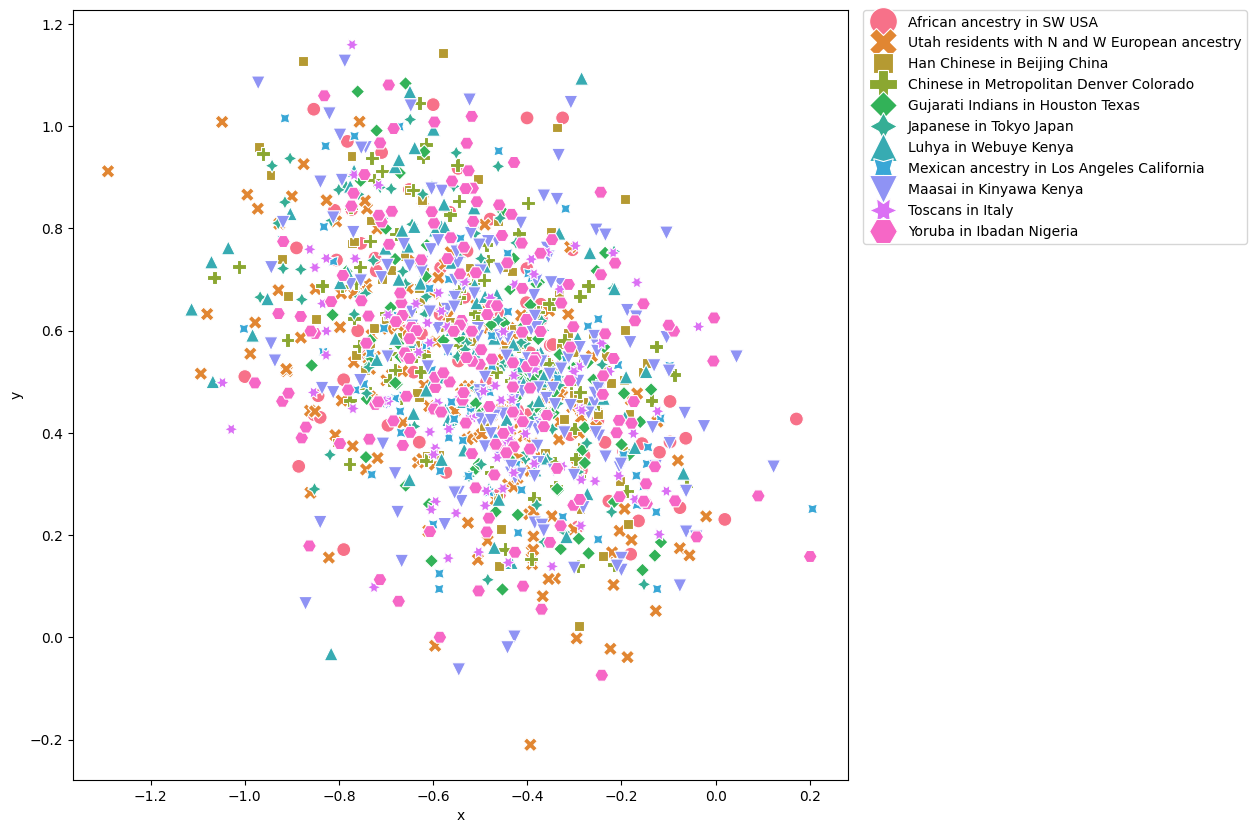

In [36]:
embeded_points = encoder_model.predict(geno_data.to_numpy())
print(embeded_points)

x = embeded_points[:,0]
y = embeded_points[:,1]
pop = pheno2['population']
data = {'x':x, 'y':y, 'pop':pop}
plt.figure(figsize = (10,10))
sns.scatterplot(x='x', y='y', data=data, hue='pop', style='pop', s=100)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, markerscale=2)
plt.show()

This is just a straight up failure of my architecture. My guess would be that the Regularization was too strong and prevented the model from learining anything meaningful. Instead the loss was minimized by just getting as close as possible to the center of the latent space. Maybe this approach could be saved by reducing or removing the regularization and possibly a lower dropout.

In conclusion:
My first approach was solid and the improvements I decided to employ don't seem to improve the understanding of the data. While the MAE was still an interesting result, the last approach would need to be heavily improved.